<a href="https://colab.research.google.com/github/leonchen112208-del/neetcode-submissions/blob/main/FitsScaler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

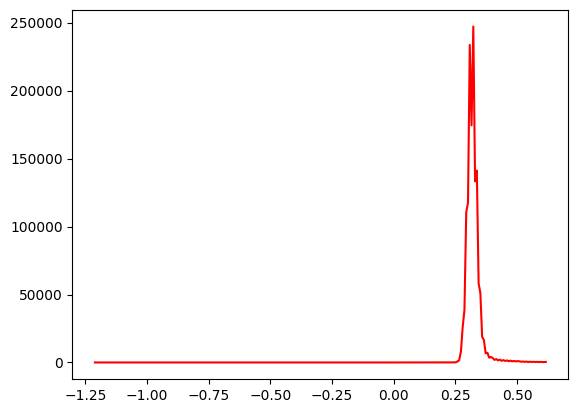

In [ ]:


from astropy.io import fits
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load the red, green, and blue FITS images
red_image = fits.open('/content/drive/MyDrive/Messier 63 rp.fit')[0]
red_exp = red_image.header['EXPTIME']
red_image = 0.5*red_image.data/red_exp

green_image = fits.open('/content/drive/MyDrive/Messier 63 V.fit')[0]
green_exp = green_image.header['EXPTIME']
green_image = 1.35*green_image.data/green_exp


blue_image = fits.open('/content/drive/MyDrive/Messier 63 B.fit')[0]
blue_exp = blue_image.header['EXPTIME']
blue_image = 1.75*blue_image.data/blue_exp



min_val = 0
max_val = 255



# Create a histogram for each image
red_hist, _ = np.histogram(red_image.ravel(), bins=256, range =(np.min(red_image),2* np.median(red_image)))
x = red_hist
green_hist, _ = np.histogram(green_image.ravel(), bins=256, range=(np.min(green_image),2* np.median(green_image)))
x = green_hist
blue_hist, _ = np.histogram(blue_image.ravel(), bins=256, range=(np.min(blue_image),2* np.median(blue_image)))
x = blue_hist
x = np.linspace(np.min(red_image),2* np.average(red_image),256)

plt.plot(x,red_hist, color='red', label='Red')








red_image = red_image.astype(np.float128)
green_image = green_image.astype(np.float128)
blue_image = blue_image.astype(np.float128)
white_image = (red_image**2 + green_image**2 + blue_image**2)**.5









black = np.median(white_image)*0.5
black_red = np.median(red_image)*0.7
black_green = np.median(green_image)*0.995
black_blue = np.median(blue_image)*0.92

contrast = np.std(white_image)*0.375



red_image = red_image.astype(np.float128)
red_image= red_image - black_red  #<-----
red_image[red_image < 0] = 0
red_image= red_image/(contrast)
red_image[red_image > 1] = 1
red_image = red_image * 255
red_image = red_image.astype(np.uint8)








green_image = green_image.astype(np.float128)
green_image= green_image - black_green
green_image[green_image < 0] = 0
green_image= green_image/(contrast)
green_image[green_image > 1] = 1
green_image = green_image * 255
green_image = green_image.astype(np.uint8)








blue_image = blue_image.astype(np.float128)
blue_image = blue_image - black_blue
blue_image[blue_image < 0] = 0
blue_image= blue_image/(contrast)
blue_image[blue_image > 1] = 1
blue_image = blue_image * 255
blue_image = blue_image.astype(np.uint8)








rgb_array = np.zeros((red_image.shape[0], red_image.shape[1], 3), dtype=np.uint8)
rgb_array[:, :, 0] = red_image
rgb_array[:, :, 1] = green_image
rgb_array[:, :, 2] = blue_image










# Save the RGB image as a JPG file
Image.fromarray(rgb_array).save('rgb.jpg')